In [75]:
from sklearn.neighbors import NearestNeighbors
import glob
import pandas as pd
from astropy.cosmology import Planck18
from astropy import units as u
import numpy as np
from astropy.coordinates import SkyCoord
from scipy.stats import norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [76]:
target = pd.read_csv('../all_sample_20260702.csv')
tg_d = Planck18.comoving_distance(target.paliya_Z).value
tg_ra = (target.paliya_RA).values
tg_dec = (target.paliya_DEC).values

coord = SkyCoord(ra = tg_ra * u.deg, dec = tg_dec * u.deg, distance = tg_d * u.Mpc)
x = coord.cartesian.x.value
y = coord.cartesian.y.value
z = coord.cartesian.z.value
tg_df = pd.DataFrame({'x':x, 'y':y, 'z':z})

In [77]:
from astropy.coordinates import Distance

def compute_index_for_target(i):
    file_list = glob.glob(f'../data/catalog/ps1/redshift_STRM/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
    if len(file_list) == 0:
        return -999

    df = pd.read_csv(file_list[0])
    surround_z = df['z_phot0'].values
    surround_err = df['z_photErr'].values

    mask = (surround_z - surround_err / 2) > -1
    surround_z = surround_z[mask]
    surround_err = surround_err[mask]
    surround_ra = df.raMean.values[mask]
    surround_dec = df.decMean.values[mask]

    surround_d = Planck18.comoving_distance(surround_z).value
    valid = np.isfinite(surround_d) & (surround_d >= 0)
    surround_z = surround_z[valid]
    surround_err = surround_err[valid]
    surround_ra = surround_ra[valid]
    surround_dec = surround_dec[valid]
    surround_d = surround_d[valid]

    if len(surround_d) == 0:
        return -999

    z_low = np.maximum(surround_z - surround_err / 2, 0)
    surround_scale = (Planck18.comoving_distance(surround_z + surround_err / 2) -
                      Planck18.comoving_distance(z_low)).value
    surround_odds = np.abs(
        norm.cdf(tg_d[i] - (5 * u.Mpc).value, loc=surround_d, scale=surround_scale)
        - norm.cdf(tg_d[i] + (5 * u.Mpc).value, loc=surround_d, scale=surround_scale)
    )

    coord = SkyCoord(ra=surround_ra * u.deg, dec=surround_dec * u.deg, distance=surround_d * u.Mpc)
    x = coord.cartesian.x.value
    y = coord.cartesian.y.value
    z = coord.cartesian.z.value

    df_surround = pd.DataFrame({'x': x, 'y': y, 'z': z})
    nn = NearestNeighbors(n_neighbors=max(1, int(len(df_surround) / 2)), algorithm='auto')
    nn.fit(df_surround)
    neighbors = nn.kneighbors(tg_df.loc[[i]])
    k_index = np.where(np.cumsum(surround_odds[neighbors[1][0]]) >= 5)[0]
    if len(k_index) == 0:
        return -999
    return int(neighbors[1][0][k_index[0]])

index = np.array(Parallel(n_jobs=-1, verbose=5)(delayed(compute_index_for_target)(i) for i in range(len(tg_df))))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:   19.5s
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:   44.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 492 out of 492 | elapsed:  1.3min finished


In [78]:
index_arr = np.array(index)

In [81]:
dens = []
for i, idx in enumerate(index_arr):
    if idx == -999:
        continue
    idx = int(idx)
    file_list = glob.glob(f'../data/catalog/ps1/redshift_STRM/t{tg_ra[i]:08.4f}{tg_dec[i]:+07.4f}.csv')
    df = pd.read_csv(file_list[0])
    df = df[['z_phot0', 'raMean', 'decMean']].iloc[idx]
    df['D_L_Mpc'] = Planck18.comoving_distance(df.z_phot0)
    coords = SkyCoord(ra = df.raMean * u.deg, dec = df.decMean * u.deg, distance = df.D_L_Mpc * u.Mpc)
    coords = np.array([coords.cartesian.x.value, coords.cartesian.y.value, coords.cartesian.z.value])

    fifth_dis = np.linalg.norm(tg_df.loc[i].values - coords)
    fifth_dens =  5 / np.pi /fifth_dis**2 /10
    fifth_dens = np.log(fifth_dens)
    dens.append(fifth_dens)

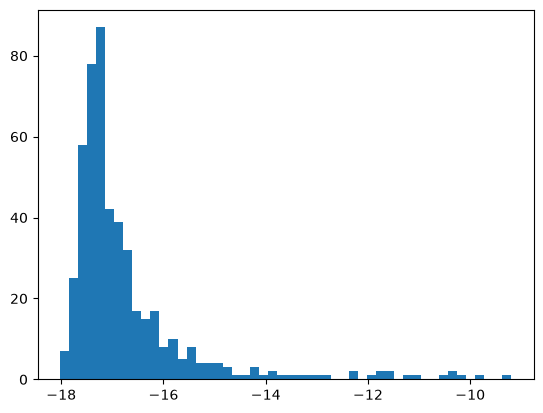

In [82]:
plt.hist(dens, bins = 50)
plt.show()